# Assignment 2: Neural Network - Time Series - ECG

Author:  
Ismail Mohammed

## Imports

In [3]:
import pandas as pd
import numpy as np
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from utility_functions import load_raw_data, aggregate_diagnostic
from pandas import read_csv
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, Conv1D, BatchNormalization, MaxPooling1D, Input
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, multilabel_confusion_matrix, accuracy_score, roc_auc_score

## Task 1: Neural Network Design

### Load Data

I started off with loading in the 100 Hz data instead of the 500 Hz. The reasoning for that was that every ECG recording was 10 seconds long, with 1oo Hz that would be 1000 datapoints for every recording and that seemed more than appropriate. This also leads to smaller data that we would have to work with later and reduce the training time of the model. 

In [ ]:
path = 'raw_data/'
sampling_rate=100

# load and convert annotation data
Y = pd.read_csv(path+'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

X = load_raw_data(Y, sampling_rate, path)

In [ ]:
print("X shape:", X.shape)

X shape: (21799, 5000, 12)


### Subclasses

Here I set up the 23 diagnostic sublasses as my target variables (Y). The task told us that there were more classes than described in the web-page and that they should also be classified. That was presumably about the 5 superclasses, so I saw that there were either 23 subclasses or 71 SCP-ECG statements. I thought that attempting to classify all 71 statements would lead to a lot of labels having far too few instances for the model to pick up any meaningful patterns, instead choosing the 23 subclasses felt like a good balance. 

In [ ]:
agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

Y['diagnostic_subclass'] = Y.scp_codes.apply(lambda x: aggregate_diagnostic(x, agg_df))

In [ ]:
print("Y shape:", Y.shape)

Y shape: (21799, 28)


### Encoding : Multi Label Binarizer

The different diagnostic labels are a list of strings in our dataset. However since Neural Networks need numerical inputs, those labels need to be transformed. By using the MultiLabelBinarizer we convert these strings into a multi-hot encoded binary matrix. This basically generates a vector of length 23, where a value of 1 means you have that diagnosis and a value of 0 means that you do not. 

In [ ]:
mlb = MultiLabelBinarizer()
y_encoded = mlb.fit_transform(Y['diagnostic_subclass'])

In [ ]:
n_outputs = len(mlb.classes_)
print(f"Unique subclasses: {n_outputs}")
print(f"Classes: {mlb.classes_}")

Unique subclasses: 23
Classes: ['AMI' 'CLBBB' 'CRBBB' 'ILBBB' 'IMI' 'IRBBB' 'ISCA' 'ISCI' 'ISC_' 'IVCD'
 'LAFB/LPFB' 'LAO/LAE' 'LMI' 'LVH' 'NORM' 'NST_' 'PMI' 'RAO/RAE' 'RVH'
 'SEHYP' 'STTC' 'WPW' '_AVB']


### Data Splitting

Here I split the dataset according to the already defined strat_fold column provided by the authors in the dataset. The data was divided like this: 
- Folds 1-8 were meant for training sets and used by the model to learn the patterns of the ECG readings
- Fold 9 was the validation set and used to monitor the model during training to check how well it was doing and to avoid overfitting
- Fold 10 was the test set and strictly used for tha final evaluation of the model's performance. 

In [ ]:
train_mask = Y.strat_fold <= 8
val_mask = Y.strat_fold == 9

X_train = X[train_mask]
y_train = y_encoded[train_mask]

X_val = X[val_mask]
y_val = y_encoded[val_mask]

print(f"Träningsdata shape: {X_train.shape}")
print(f"Valideringsdata shape: {X_val.shape}")

Träningsdata shape: (17418, 5000, 12)
Valideringsdata shape: (2183, 5000, 12)


## Task 2: Layers and Architechture

I started off with having LSTM, Dropout and Dense as part of my model. I used LSTM since it's a good model to use for timeseries data, dropout was used to combat overfitting. Dropout works by randomly deactivating neurons during each training step. The last layer, Dense, was the output layer for all of the 23 subclasses. I also added Early Stopping which is another way of avoiding overfitting but can also potentially save time by ending the training earlier if it is necessary. From there on I tested different amounts of epochs, batch sizes, number of units in my LSTM layer until I found what I felt was the best possible model. 


However even after that the model felt quite lacking with less than satisfactory results and that is where I found studies that showed that using Conv1D layers works great for finding features in ECG data [1]. So I added a Conv1D layer that finds patterns/features, a Batch Normalization layer after the Conv1D to standardize and then Max Pooling to downsample the data while saving the most important features and saving time on model training. I saw that the report used a similar structure and wanted to try it myself and saw that it gave better results. AUC, Accuracy, Recall, F1 all of it went up and the training time went down, with more time and tinkering I could have maybe improved the model even more. 

- [1] https://www.nature.com/articles/s41598-020-65105-x

In [ ]:
n_outputs = 23
tf.random.set_seed(42)

model = Sequential()
model.add(Input(shape=(1000, 12)))

model.add(Conv1D(64, 5, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(LSTM(64))

model.add(Dropout(0.4))

model.add(Dense(n_outputs, activation='sigmoid'))

model.compile('adam','binary_crossentropy', 
              metrics=['accuracy' ,tf.keras.metrics.AUC(name='auc')])

### Training

Here I used Early Stopping to end the model training when the val_loss value did not improve for three consecutive epochs, to save both model training time but also to avoid overfitting. I tested several different epochs and saw that thanks to the early stopping it very rarely went over 30 epochs so I put it at 35 and let the Early Stopping handle actually stopping it when it fits.

For the batch size I also tested 32, 64, 128 and other multiplications of 2 and I saw that 32 gave the best results and did not affect the training time to much

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    mode='auto',
    patience=3,
    restore_best_weights=True
)

model.fit(X_train, y_train,
    epochs=35, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop])

## Task 5: Model Evaluation

Here I isolate the test data using the previously mentioned defined strat_fold and use it to evaluate the model

In [ ]:
# Mask for testdata
test_mask = Y.strat_fold == 10

X_test = X[test_mask]
y_test = y_encoded[test_mask]

test_results = model.evaluate(X_test, y_test, verbose=1)

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6160 - auc: 0.9472 - loss: 0.1086


The model predicts the probability of each disease with a score between 0 and 1. Usually, we use 0.5 as the cutoff point. But because our dataset has very few examples of some rare diseases, the model is often unsure and gives low scores. Using 0.5 meant that the model missed many sick patients, for example Recall was 0 for a lot of the smaller classes

To fix this, I lowered the threshold to 0.2. This means the model will guess "positive" more easily. By lowering the threshold, the model found many more of the rare diseases, which improved the Recall and F1-scores.

In [ ]:
y_pred_prob = model.predict(X_test)

y_pred_binary = (y_pred_prob > 0.2).astype(int)

print(f"Accuracy: {accuracy_score(y_test, y_pred_binary):.4f}\n")

auc_score = roc_auc_score(y_test, y_pred_prob, average='macro')
print(f"Test AUC: {auc_score:.4f}\n")

print("Classification Report")
print(classification_report(y_test, y_pred_binary, target_names=mlb.classes_, zero_division=0))

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Accuracy: 0.4600

Test AUC: 0.8664

Classification Report
              precision    recall  f1-score   support

         AMI       0.60      0.77      0.68       306
       CLBBB       0.80      0.87      0.83        54
       CRBBB       0.68      0.94      0.79        54
       ILBBB       0.00      0.00      0.00         8
         IMI       0.59      0.64      0.61       327
       IRBBB       0.51      0.78      0.62       112
        ISCA       0.28      0.27      0.27        93
        ISCI       0.89      0.20      0.33        40
        ISC_       0.49      0.75      0.59       128
        IVCD       0.25      0.03      0.05        79
   LAFB/LPFB       0.59      0.78      0.67       179
     LAO/LAE       0.00      0.00      0.00        42
         LMI       0.00      0.00      0.00        20
         LVH       0.54      0.81      0.65       214
        NORM       0.73      0.97      0.83       963
        NST_       0.19      0.04    

Standard metrics like Accuracy did not work well for this dataset because it has 23 classes and is very imbalanced. It had many healthy patients and few sick ones. Because of that I avoided Accuracy and used Macro averaged AUC, F1-score and Recall to judge my models.

I avoided Accuracy because it only gives a point if the model guesses all 23 diseases perfectly for a patient. This is too strict and makes the model look worse than it actually is.

Macro Averaged AUC was the metric I looked most at. That is because AUC measures how well the model is able to seperate the sick patients from the healthy ones

I used F1-score and Recall to see how the model performed on each specific disease. F1-score is much better than Accuracy when the data is imbalanced, because it balances false alarms (Precision) and missed diseases (Recall).

## Confusion Matrix

To really understand where the model succeeds and where it fails, I created a Confusion Matrix for each of the 23 classes. Because a patient can have multiple diseases at the same time, we cannot use a single standard matrix. Instead I used a Multilabel Confusion Matrix to generate 23 separate 2x2 matrices for each disease.

We can see that the model is very good at identifying healthy patients because the model had a lot of data for that class. Because I lowered the threshold to 0.2 the model casts a wider net and we see that in some of the smaller classes. However that also increased the amount of False Positives. 

For the really rare classes like LMI and SEHYP we can see that the model is quite bad at identifying that but that is solely because of the low amount of data during the training on those classes. 

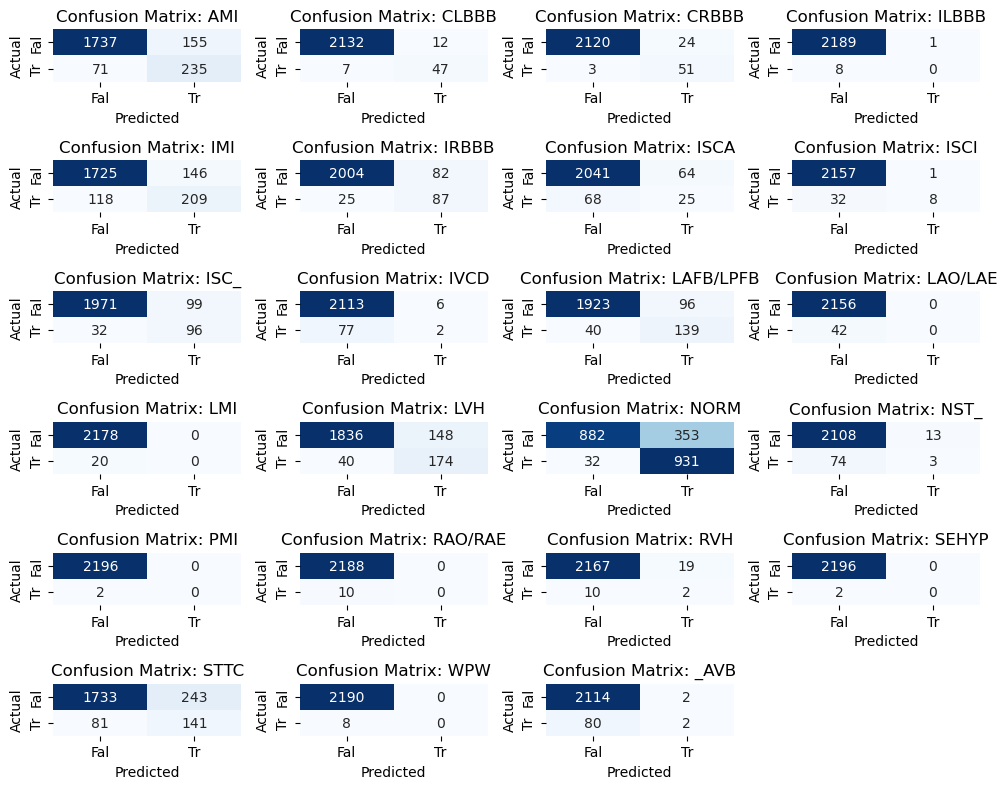

In [ ]:
mcm = multilabel_confusion_matrix(y_test, y_pred_binary)

fig, axes = plt.subplots(6, 4, figsize=(10, 8))
axes = axes.ravel()

for i in range(23):
    ax = axes[i]
    sns.heatmap(mcm[i], annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'Confusion Matrix: {mlb.classes_[i]}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    
    # Shortened labels for better fit
    ax.set_xticklabels(['Fal', 'Tr'])
    ax.set_yticklabels(['Fal', 'Tr'])

axes[23].axis('off')
plt.tight_layout()
plt.show()

# Task 6: Feature Importance

Unlike the previous lab where we could simply pull out the most important features from our Random Forest model we have to figure it out ourselves. What I chose to do was test our 12 leads and see which one of them had the greatest effect on the AUC score, since I thought of that one as the most important one.

I did this by going through every feature one by one and replacing all values in one features with zeros, tested the model to make predictions without that specific lead/feature and measured the new AUC score. By then measuring how much the AUC score dropped I could then see which lead was more important for good predictions. 

Base AUC: 0.8664

Sänkt AUC utan Lead I: 0.0035
Sänkt AUC utan Lead II: -0.0016
Sänkt AUC utan Lead III: 0.0014
Sänkt AUC utan Lead aVR: 0.0035
Sänkt AUC utan Lead aVL: 0.0012
Sänkt AUC utan Lead aVF: -0.0008
Sänkt AUC utan Lead V1: 0.0117
Sänkt AUC utan Lead V2: 0.0024
Sänkt AUC utan Lead V3: -0.0028
Sänkt AUC utan Lead V4: 0.0013
Sänkt AUC utan Lead V5: 0.0133
Sänkt AUC utan Lead V6: 0.0049


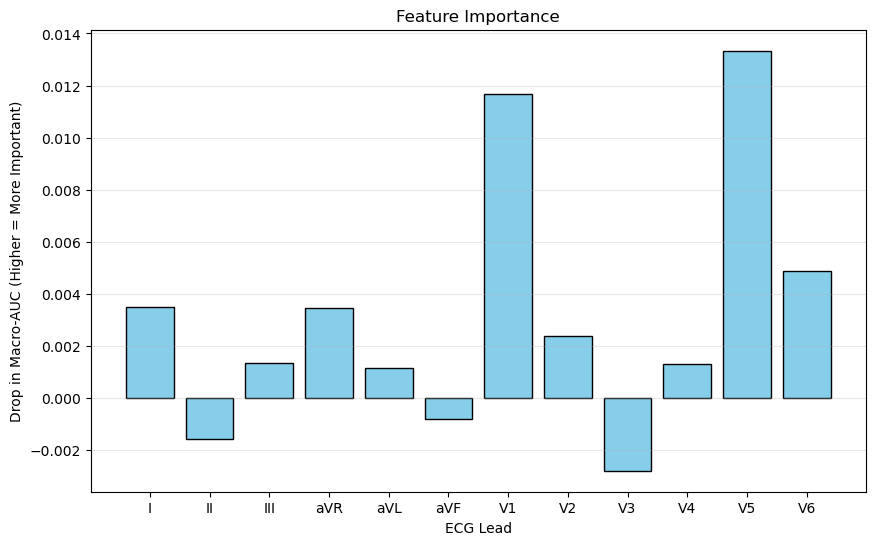

In [ ]:
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

y_pred_base = model.predict(X_test, verbose=0)
base_auc = roc_auc_score(y_test, y_pred_base, average='macro')
print(f"Base AUC: {base_auc:.4f}\n")

importance_scores = []

for i in range(12):
    X_test_new = np.copy(X_test)
    
    X_test_new[:, :, i] = 0
    
    y_pred_new = model.predict(X_test_new, verbose=0)
    
    new_auc = roc_auc_score(y_test, y_pred_new, average='macro')
    
    drop_in_auc = base_auc - new_auc
    importance_scores.append(drop_in_auc)
    
    print(f"Lowered AUC without Lead {lead_names[i]}: {drop_in_auc:.4f}")

plt.figure(figsize=(10, 6))
plt.bar(lead_names, importance_scores, color='skyblue', edgecolor='black')
plt.title('Feature Importance')
plt.xlabel('ECG Lead')
plt.ylabel('Drop in AUC')
plt.grid(axis='y', alpha=0.3)
plt.show()

After doing this test I found that the leads V5, V1 and V6 were the most important features. 

## Results and Discussion

- The biggest hurdle in this dataset was the extreme difference in the number of patients for each disease. Because it is a multi-label problem, methods like oversampling could not be used easily.

- Combining a Conv1D layer with an LSTM layer was highly effective. The CNN extracted the shapes of the ECG waves, while the LSTM analyzed the rhythm over the 10-second recording.

- The Feature Importance test proved that the neural network did not just guess randomly but it relied heavily on specific ECG leads to make its decisions.

In [ ]:
model.save('models/LSTM_40_2602211601.keras')